# Ising Model Theory
### Defining The Ising Model
We start with 2d lattice where each lattice site $i$ has a corresponing 'spin' $ \sigma_i \in \{-1, +1\} $. The microstate of lattice spins is notated by $\boldsymbol{\sigma}$. A Hamiltonian of a state $\boldsymbol{\sigma}$ in the Ising Model (in the absence of an external field) is defined by
$$H(\boldsymbol{\sigma}) = -\sum_{\langle i j \rangle} J_{ij} \sigma_i \sigma_j \tag{1}
$$
Where $\langle i j \rangle$ indicates $i$ and $j$ are adjacent lattice sites and $J_{ij}$ is the 'coupling strength' between given sites. In this experiment $J_{ij}$ is set equal to $1$ for all interactions and the Hamiltonian becomes simply
$$H(\boldsymbol{\sigma}) = -\sum_{\langle i j \rangle} \sigma_i \sigma_j \tag{2}
$$
The probability of any given state in a thermodynamic system in equilibrium at temperature $T$ coresponding to Bolzman factor $\beta = 1/(k_BT)$ is given by 
$$ p(\boldsymbol{\sigma}) = \frac{e^{-\beta H(\boldsymbol{\sigma})}}{Z} \tag{3}
 $$
where $Z_{\beta}$ is the partition function 
$$ Z = \sum_{\boldsymbol{\sigma}} e^{-\beta H(\boldsymbol{\sigma})}  \tag{4}
$$


## Computational Algorithms
Numerically simulating the Ising Model to produce representative statistics requires the above equations be satisfied aswell as that the simulation be in an equilibrium state. One method to ensure equilibrium is by ensuring condition of **detailed balance**. That is, that for any two microstates $\nu$ and $\mu$.
$$p(\mu) P(\mu \to \nu) =p(\nu) P(\nu \to \mu) \tag{5}
$$
### The Metropolis Hastings Algorythm
The Metropolis Hastings Algorythm is one such algorythm that satisfies detailed balance by only changing one spin state $\sigma_i$ at a time (so for any $\nu$ and $\mu$ with more than one spin states difference $P(\mu \to \nu) = P(\nu \to \mu) = 0$ for a given simulation step). To Satisfy $(5)$, $P(\mu \to \nu)$ and $P(\nu \to \mu)$ must be chosen such that  
$$
\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = \frac{p(\nu)}{p(\mu)} = \frac{\frac{e^{-\beta H(\nu)}}{Z}}{\frac{e^{-\beta H(\mu)}}{Z}} = e^{-\beta(H(\nu)-H(\mu))} \tag{6}
$$
This can be done by the following method:
Let $\nu$ be the current state
Choose a random lattice site and let $\mu$ be the proposed state of flipping the spin on the chosen lattice site, the probability to be computed is $P(\nu \to \mu)$ 
1) Choose a random lattice site 
2) Calculate $\Delta H = H(\nu)-H(\mu)$
3) - If $\Delta H > 0$,
set $P(\mu \to \nu) = 1$, then to satisfy $(6)$, let $P(\nu \to \mu) = e^{-\beta(\Delta H)}$ 
    - Else if $\Delta H < 0$,
by symetry of the above line, let $P(\nu \to \mu) = 1$  

These steps can be repeated and will produce true Ising Model statistics as the number of steps goes to infinity. This is one of the simplest ways to simulate the Ising Model

### The Swendsen-Wang Algorythm
The Metropolis-Hastings algorythm produces true statistics as the number of steps goes to infinity, and produces sufficiently accurate statistics in a finite number of steps for temperatures above and bellow the critical temperature. However around the critical temperature the number of steps required to produce representative distributions goes to infitity, this phenomenon is known as **Critical Slowing Down**, see URL for a more in depth investigation. In order to study the system at criticality, for example, to find the **Critical Exponents**. An algorythm must be used that is computationally stable at and around the critical temperature. One algorythm which satisfies this requirement is the Swendsen-Wang Algorythm. Bellow we will show it also satisfies detailed balance for the Ising Model. 

As before, start with a state given by $\mu$. The Swendsen-Wang Algorythm works by finding many possible $\nu$ and tranforming to any found state $\nu$ with uniform probability. This works by introducing a new element, for each pair of adjacent lattice sites $i$ and $j$ assign a 'bond' variable $d_{i,j} \in \{0, 1\}$ these are assigned according to a probability distribution conditional on the spin states $\mu_i$ and $\mu_j$ contained in $\mu$. New states $\nu$ are then derived directly from the bond configuration $d$.

This can be thought of as splitting the probability $P(\nu \to \mu)$ into conditional probabilities $P(\nu \to \mu) = \sum_{d \in D}{P(\mu \mid d)P(d \mid \nu)}$ where $D$ is the set of all possible bond states. The procedure is as follows:

1) Bond Formation Step:
    for each bond variable $d_{i,j}$, set to 1 with the following probabilities
    $$
    P(d_{i,j} = 1) =
    \begin{cases} 
    1 - e^{-2\beta}, & \text{if }  \mu_i = \mu_j \\
    0, & \text{if } \mu_i \neq \mu_j
    \end{cases}
    $$

    $$
    P(d_{i,j} = 1 \mid \mu_i = \mu_j) = 1 - e^{-2\beta J}\\
    P(d_{i,j} = 0 \mid \mu_i = \mu_j) = e^{-2\beta J}\\
    P(d_{i,j} = 1 \mid \mu_i \neq \mu_j) = 0\\
    P(d_{i,j} = 0 \mid \mu_i \neq \mu_j) = 1
    $$
2) Clustering Step:
    Any two lattice sites $i$ and $j$ which are connected by a bond d_{i,j} = 1, must have the same spin in $\mu$.  Even if lattice sites are not adjacent, if there are bonds which connect them via intermediate lattice sites, the previous condition nececitates that they must have the same spin. In this way, clusters can be formed. A clustering algorythm can be used to complete this step, given a bond configuration $d$

3) Cluster flipping step:
    Given the space of possible $\mu$'s with each cluster being of one spin, a final $\mu$ can be picked uniformly by simply assigning each cluster either spin 1 or -1 with a probability of 1/2

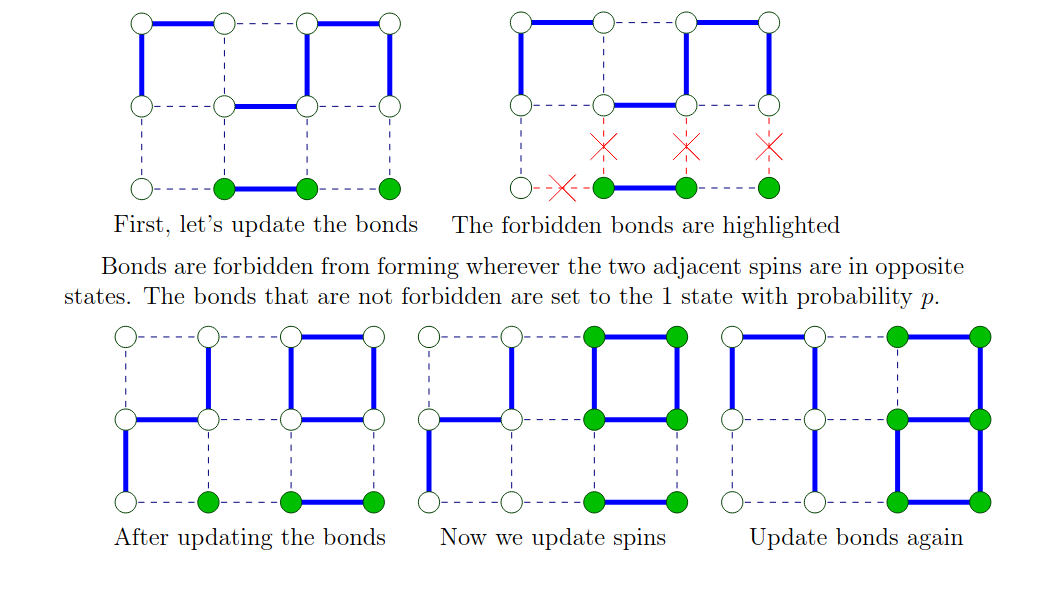
From https://www.inference.org.uk/itila/swendsen.pdf

As for the Metropolis Hastings Algorithm we want to show
$$
\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = \frac{\sum_{d \in D}{P(\nu \mid d)P(d \mid \mu)}}{\sum_{d \in D}{P(\mu \mid d)P(d \mid \nu)}} = e^{-\beta(H(\nu)-H(\mu))}
$$




Any bond state $d$ that can be accessed from a spin state in step 1, can also produce that same spin state in step 3. In other words the process is reversable. This implies that the bond states where both $P(\nu \mid d)$ and $P(d \mid \mu)$ are non-zero are the same as the bond states where both $P(\mu \mid d)$ and $P(d \mid \nu)$ are non-zero and we can denote this set of accessible bond states by $D_{\nu,\mu}$. So the sum can be rewritten as 

$$
\frac{{\sum_{d \in D_{\nu,\mu}}P(\nu \mid d)P(d \mid \mu)}}{{\sum_{d \in D_{\nu,\mu}}P(\mu \mid d)P(d \mid \nu)}}
$$

Now, let's decompose the conditional probability of $d$ given a state $\sigma$


$$
\begin{aligned}
P(d \mid \sigma) = \prod_{\langle i j \rangle} & \Big[  P(d_{i,j}=1 \mid \sigma_i = \sigma_j) d_{i,j} \delta_{\sigma_i, \sigma_j}  \\
& + P(d_{i,j}=0 \mid \sigma_i = \sigma_j)(1 - d_{i,j})  \delta_{\sigma_i, \sigma_j} \\
& +  P(d_{i,j}=1 \mid \sigma_i \neq \sigma_j) d_{i,j} (1 - \delta_{\sigma_i, \sigma_j}) \\
& + P(d_{i,j}=0 \mid \sigma_i \neq \sigma_j)(1 - d_{i,j}) (1 - \delta_{\sigma_i, \sigma_j}) \Big]
\end{aligned}
$$









$$
P(d \mid \sigma) = \prod_{\langle i j \rangle} \Bigg[
(1 - e^{-2\beta J}) d_{i,j} \delta_{\sigma_i, \sigma_j} 
+ e^{-2\beta J} (1 - d_{i,j}) \delta_{\sigma_i, \sigma_j} 
+ (1 - d_{i,j}) (1 - \delta_{\sigma_i, \sigma_j})
\Bigg]
$$

Consider the term $(1 - d_{i,j})(1 - \delta_{\sigma_i, \sigma_j})$. If $\delta_{\sigma_i, \sigma_j} = 1$, ie the sites i and j have the same spin, the term becomes 0 invarient of $d_{i,j}$. If $\delta_{\sigma_i, \sigma_j} = 0$, and the sites have opposing spins, we have that the probability $P(d_{i,j} = 0 \mid \sigma_i \neq \sigma_j) = 1$  which enforces that $d_{i,j} = 0$. Therfore, we can rewrite the term simply as $(1 - \delta_{\sigma_i, \sigma_j})$. We also factorise ou the $\delta_{\sigma_i, \sigma_j}$ from the first two terms.    

$$
P(d \mid \sigma) = \prod_{\langle i j \rangle} \Bigg[
((1 - e^{-2\beta J}) d_{i,j} 
+ e^{-2\beta J} (1 - d_{i,j})) \delta_{\sigma_i, \sigma_j} 
+ (1 - \delta_{\sigma_i, \sigma_j})
\Bigg]
$$

Applying the identity for a binary variable $x \in \{0, 1\}$

$$
ax + b(1-x) \equiv a^xb^{1-x}
$$

for the bracketed terms with respect to $d_{i,j}$ and then for the whole sum with respect to $\delta_{\sigma_i, \sigma_j}$

$$
P(d \mid \sigma) = \prod_{\langle i j \rangle} \Bigg[
\left( (1 - e^{-2\beta J})^{d_{i,j}} e^{-2\beta J (1 - d_{i,j})} \right)^{\delta_{\sigma_i, \sigma_j}}1^{1-\delta_{\sigma_i, \sigma_j}}
\Bigg] = \prod_{\langle i j \rangle} \Bigg[
\left( (1 - e^{-2\beta J})^{d_{i,j}} e^{-2\beta J (1 - d_{i,j})} \right)^{\delta_{\sigma_i, \sigma_j}}
\Bigg] \\= \prod_{\langle i j \rangle} \Bigg[
\left( e^{-2\beta J} (e^{2\beta J} - 1)^{d_{i,j}} \right)^{\delta_{\sigma_i, \sigma_j}}
\Bigg]
=\prod_{\langle i j \rangle} e^{-2\beta J\delta_{\sigma_i, \sigma_j}} \Bigg[
\left(  (e^{2\beta J} - 1)^{d_{i,j}} \right)^{\delta_{\sigma_i, \sigma_j}}
\Bigg]
\\= {e^{-\sum_{\langle i j \rangle}2\beta J\delta_{\sigma_i, \sigma_j}}}\prod_{\langle i j \rangle}  \Bigg[  (e^{2\beta J} - 1)^{{d_{i,j}}{\delta_{\sigma_i, \sigma_j}}}
\Bigg]
$$

Lets look at 

$$
P(\mu \to \nu) = {\sum_{d \in D_{\nu,\mu}}P(\nu \mid d)P(d \mid \mu)} \\=
\sum_{d \in D_{\nu,\mu}}\Bigg[P(\nu \mid d){e^{-\sum_{\langle i j \rangle}2\beta J\delta_{\mu_i, \mu_j}}}\prod_{\langle i j \rangle}  \Bigg[ (e^{2\beta J} - 1)^{{d_{i,j}}{\delta_{\mu_i, \mu_j}}}
\Bigg]\Bigg] \\=
{e^{-\sum_{\langle i j \rangle}2\beta J\delta_{\mu_i, \mu_j}}}\sum_{d \in D_{\nu,\mu}}\Bigg[P(\nu \mid d)\prod_{\langle i j \rangle}  \Bigg[  (e^{2\beta J} - 1)^{{d_{i,j}}{\delta_{\mu_i, \mu_j}}}
\Bigg]\Bigg]
$$

Similarly,
$$
P(\nu \to \mu) = {e^{-\beta\sum_{\langle i j \rangle}2 J\delta_{\nu_i, \nu_j}}}\sum_{d \in D_{\nu,\mu}}\Bigg[P(\nu \mid d)\prod_{\langle i j \rangle}  \Bigg[  (e^{2\beta J} - 1)^{{d_{i,j}}{\delta_{\nu_i, \nu_j}}}
\Bigg]\Bigg]
$$

Since  for $d \in D_{\nu,\mu}$, $\mu$ and $\nu$ are both accessable states, for any $d_{i,j} = 1$, this enforces that $\delta_{\mu_i, \mu_j}$ and $\delta_{\nu_i, \nu_j}$ must equal 1. It can be seen that ${d_{i,j}}{\delta_{\mu_i, \mu_j}} = {d_{i,j}}{\delta_{\nu_i, \nu_j}} = {d_{i,j}}$



Now, we can write 

$$
\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = 
e^{-\beta\sum_{\langle i j \rangle}2 J(\delta_{\mu_i, \mu_j}-\delta_{\nu_i, \nu_j})}\frac{\sum_{d \in D_{\nu,\mu}}\Bigg[P(\nu \mid d)\prod_{\langle i j \rangle}  \Bigg[  (e^{2\beta J} - 1)^{{d_{i,j}}}
\Bigg]\Bigg]}{\sum_{d \in D_{\nu,\mu}}\Bigg[P(\nu \mid d)\prod_{\langle i j \rangle}  \Bigg[  (e^{2\beta J} - 1)^{d_{i,j}}
\Bigg]\Bigg]}
$$

Since $P(\nu \mid d) = P(\mu \mid d)$ for any given state $d$, and the sums are otherwise independent of $\nu$ and $\mu$, the fraction simplifies to 1, and it can finally be seen that the relationship simplifies to 


$$
\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = 
e^{-\beta\sum_{\langle i j \rangle}2 J(\delta_{\mu_i, \mu_j}-\delta_{\nu_i, \nu_j})}= 
e^{-\beta\sum_{\langle i j \rangle} J(2\delta_{\mu_i, \mu_j}-1-2\delta_{\nu_i, \nu_j}+1)}= 
e^{-\beta(\sum_{\langle i j \rangle} J(2\delta_{\mu_i, \mu_j}-1)-(-\sum_{\langle i j \rangle} J(2\delta_{\nu_i, \nu_j}-1)))}\\=
e^{-\beta(H(\nu)-H(\mu))}
$$


As required. And so the Swendsen-Wang Algorythm satisfies detailed balance and will produce Ising Model Statistics. This overlengthy form of a proof/ line of reasonning for the detailed balance of the Swendsen-Wang algorythm was written by me and the logic was not directly copied from any other sources.  

# Phase Transitions

## Mean Field Solution

The mean field approximation is a method of simplifying the system by replacing individual spin-spin interactions with spin-field interaction. Since we are working with model without an external field, the field we substitute is an 'effective field' which is the the mean of the spin's neighbour's. The effective field

$$
B_{eff} = 4\langle \sigma_j \rangle
$$
Is the sum of the neighbors on the 4 $j$ neighbor sites assuming they all have average spin $\langle \sigma_j \rangle$
This approximation produces the adjusted Hamiltonian

$$
H(\boldsymbol{\sigma}) = -\sum_{i} B_{eff}\sigma_i 
$$



Since each part of the hamiltonian is now dependent only on the 'field' $B_{eff}$ and the individual spin $\sigma_i$, we can treat each spin as being dependent on it's own Hamiltonian  
$$
H_i = B_{eff}\sigma_i 
$$

For a given spin $\sigma_i$, it is assumed that on average it has the same spin as it's neighbors ie $\langle \sigma_i \rangle = \langle \sigma_j \rangle$. We can express $\langle \sigma_i \rangle$ by it's probability

$$
\langle \sigma_i \rangle = \frac{1}{Z}\sum_i{\sigma_i e^{-H_i}} = \frac{1}{Z}\sum_i{\sigma_i e^{-\beta B_{eff}\sigma_i}} = \frac{e^{\beta B_{eff}}-e^{-\beta B_{eff}}}{e^{\beta B_{eff}}+e^{-\beta B_{eff}}} =\tanh(\beta B_{eff})= \tanh(4 \beta \langle \sigma_j \rangle )
$$

So 

$$
\langle \sigma_i \rangle = \tanh(4 \beta \langle \sigma_i \rangle )
$$


This equation cannot be solved analytically but it can be plotted to study it's behaviour. A demonstration was made here (URL)

If we taylor expand the expression $\tanh(4 \beta \langle \sigma_i \rangle )$ around 0, we have. 
$$
\tanh(4 \beta \langle \sigma_i \rangle ) = 4 \beta \langle \sigma_i \rangle - \frac{(4 \beta \langle \sigma_i \rangle)^3}{3} + \mathcal{O}((4 \beta \langle \sigma_i \rangle)^5)
$$

$$
\langle \sigma_i \rangle = 4 \beta \langle \sigma_i \rangle - \frac{(4 \beta \langle \sigma_i \rangle)^3}{3} + \mathcal{O}((4 \beta \langle \sigma_i \rangle)^5)
$$



$$
\langle \sigma_i \rangle (1 - 4\beta) = -\frac{(4\beta)^3}{3} \langle \sigma_i \rangle^3
$$

$$
\langle \sigma_i \rangle \left[ (1 - 4\beta) + \frac{(4\beta)^3}{3} \langle \sigma_i \rangle^2 \right] = 0
$$

the solutions of this equation describe the behaviour of magnetization in the Ising model.

For $(1-4\beta)>0$, the only solution is $\langle \sigma_i \rangle = 0$.\\

For $(1-4\beta)<0$, additional solutions of $$\langle \sigma_i \rangle = \pm \sqrt{\frac{3(1-4\beta)}{{4\beta}^3}} = \pm \sqrt{\frac{3}{4}(T-4)T^2}$$ appear. 

As $T_- \to 4$, 
the expression behaves as
$$\langle \sigma_i \rangle = \pm \sqrt{\frac{3}{4}(T-4)4^2} = \pm \sqrt{12(T-4)} = \pm \sqrt{12} {\lvert T-4 \rvert}^\frac{1}{2}$$


We have derived some key behaviour about the the Ising Model using some simplifications. There is a high temperature and a low temperature phase. The high temperature phase is carracterized by a net zero magentization implying that there is a mix of up and down spins on average, we can call this the dissordered phase. The low temperature phase is characterized by either posotive or negative average magetization, implying that spins tend to allign themselves, we can call this the ordered phase. There is a certain temperature at which this behaviour transitions and we call this the Critical Temperature $T_c$. Additionally, the magnetization follows a power law around the Critical Temperature
$$
\langle \sigma_i \rangle \propto {\lvert T-T_c \rvert}^\frac{1}{2}
$$
Many intrinsic quantities of the Ising model follow power laws of this nature around critical temperature. We call the exponents of these quantities, in the above case $\frac{1}{2}$, the critical exponents.

The mean field solution to the Ising Model is not numerirically accurate, however there is a glimpse into a more general understanding of these critical phenomena through the method outlined above. Looking at figure 1, with a temperature of $T=T_c=4$ the lines become tangent near the origin. This can be thought of as a point where the average magnetization can have the widest continuous range of values. If this is the case, and considering the fact that the method has no dependence on scale, this has some intersting implications. If there was local dissorder (implying a wide range of possible average magitization on a small scale) but it was granular, so as you zoomed out the system would appear smooth, the average magnetization would aproach 0 for larger system sizes. This is what happens in the high temperature system. But the fact that the average magnetization has a range independent of system size means something else is occuring. There must be structure allowing for unevenness in the system's magnetization at all scales, and of the same type. This means that the system becomes fractal at the critical temperature, and it looks similar at different scales. 

The mean field picture tries to discern the behaviour of the entire system by considering just a single spin and the system's average value. To model the Ising model more accurately will require us to consider that (at least for high and low tempereatures) spins interact with eachother more strongly on smaller scales than on larger scales. We can quantify this with the parameter of Correlation Length

## Critical exponents
### Correlation length
One key quantity to understanding the critical behaviour of the system is the correlation length $\xi(T)$.

$$
\langle (\sigma_i - \langle \sigma_i \rangle)(\sigma_j -  \langle \sigma_j \rangle) \rangle \sim e^{-\frac{|x - y|}{\xi(T)}}
$$

where x and y are the spacial position vectors of the spins $\sigma_i$ and $\sigma_j$. $\xi(T)$ represents the typical length scale at which the two spins $\sigma_i$ and $\sigma_j$ are correlated more than $1/e$

 


The behaviour of the correlation length over a range of temperatures over the critical region has great explanatory power for the behaviour of the system's other quantities. 

As with magnetization, the correlation length obeys a power law relationship around the critical temperature
$$
\xi(T) \propto {\lvert T-T_c \rvert}^{-\nu}
$$
where $\nu > 0$ is the critical exponent of correlation length

This power law means that as $T \to T_c$, $\xi(T) \to \infty$

This alligns with our previous interpretation of the average magnetism given by the mean field theory. As the system approaches the critical temperature, spins that are further apart start to influence eachother, until at the critical temperature, spins are correlated at every scale.

### Susceptibility, Specific Heat and Magnetization

The four critical exponents are $\beta$, $\gamma$, $\alpha$, $\nu$ where 

$$

    \langle |\sigma|\rangle \propto |T-T_c|^\beta\\
    \chi_M \propto |T-T_c|^{-\gamma}\\
    C_V \propto |T-T_c|^{-\alpha}\\
    \xi \propto |T-T_c|^{-\nu}

$$

Where $\chi_M =\beta​(⟨\sigma^2⟩−{⟨|\sigma|⟩}^2)$ and specific heat $C_V = \frac{\beta}{T}​(⟨\epsilon^2⟩−{⟨\epsilon⟩}^2)$ where $\epsilon = H/N^2$ is the average magetization. 
In 1944 Onsager (https://journals.aps.org/pr/pdf/10.1103/PhysRev.65.117) found these exponents analytically to be  

$$
\alpha=0, \quad \beta=0.125, \quad \gamma=1.75, \quad \nu=1
$$

## Finding The Critical exponents through numerical simulation

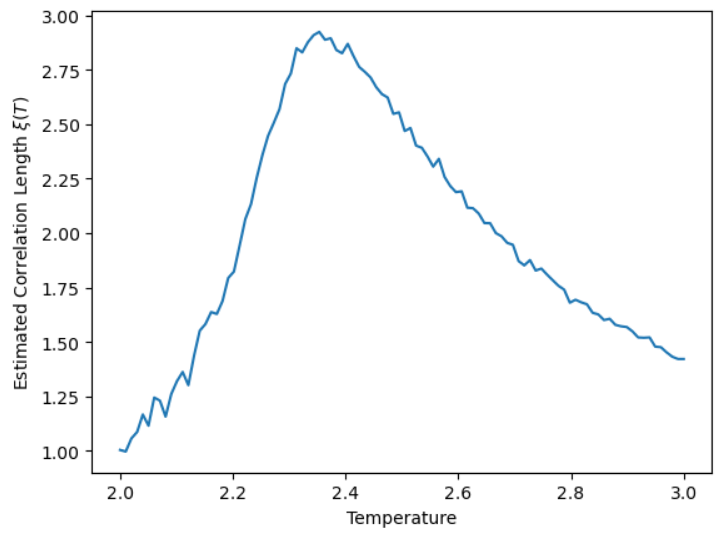

Figure 4: Correlation Length against temperature in the critical region, for an N = 32 system derived by a method outlined here(URL)

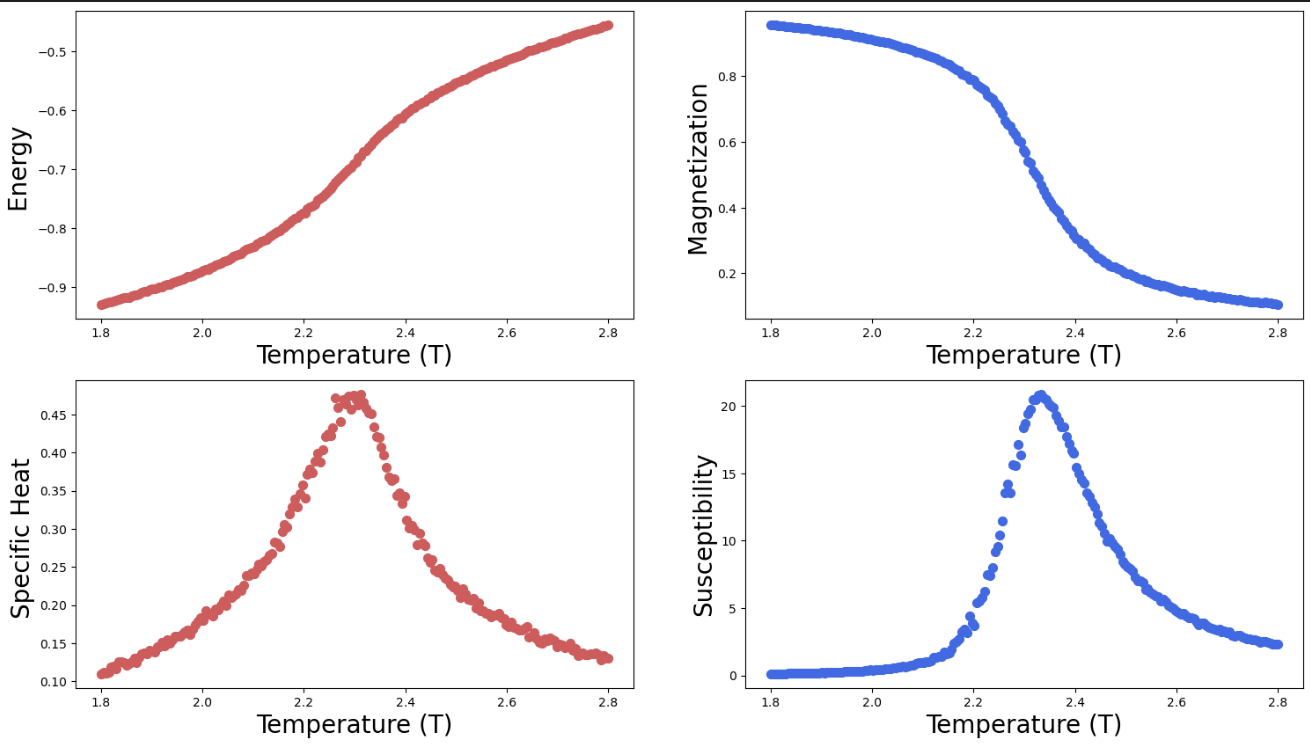

Figure 5: Above is data from an Ising Model simulation discussed here(URL) which shows the behaviour of four key quantities around the critical temperature


One of the main objectives of this lab is to find numerical estimates for the critical exponents through computational simulation. Returning to the correlation length

$$
\xi \propto |T-T_c|^{-\nu}
$$

as the temperature aproaches criticallity, any numerical simulation will be insuffiecient to accomodate a growing correlation length, we use periodic boundary conditions, meaning that effectively no two points can be more that $N$ distance away from eachother. The increase in correlation length can be thought of as source of the critical behaviour of the other system variables, and so it makes sense that where the correlation length is maximum the system behaves as if at criticality. This means that for a system of length $N$ there is a **Psudocritical** point where $\xi \sim N$ the variables will behave closest to true criticallity, and there will be a psudocritical temperature $T_c(N^2)$ at which this happens. It follows that

$$
    \xi \sim N\propto \bigg \lvert T_c(N^2) - T_c\bigg\rvert^{-\nu} \quad \Rightarrow \quad \bigg\lvert T_c(N^2) - T_c\bigg\rvert \propto N^{-1/\nu}
$$


One way we can find the Psudocritical point by measureing the peak of $\chi_M$, since this is directly caused by the increase in correlation lenths. We have
$$
\chi_{M,\text{peak}} \propto |T_c(N^2)-T_c(\infty)|^{-\gamma}  \propto N^{\gamma/\nu}
$$

It follows that

$$
    \log \chi_{M,\text{peak}} =\frac{\gamma}{\nu}\log N
$$
from which $z=\gamma/\nu$ can be found.

## The Binder Cumulant

Following on from the logic in the previous section, it can be seen that at the critical point,

$$
\langle |\sigma| \rangle \propto |T_c(N^2)-T_c(\infty)|^{\beta}  \propto N^{\beta/\nu}
$$

We introduce a distribution function $P_N(\sigma)$, $\int P_N(\sigma) d\sigma = 1$ for the Magetisation per spin $\sigma$
Now
$$
\langle |\sigma| \rangle = \int |\sigma| P_N(\sigma) d\sigma \propto N^{-\beta/\nu}
$$

It follows that $P_N(\sigma)$ can be written in the form

$$
P_N(\sigma) = N^{\beta/\nu}P(u), u = \sigma N^{\beta/\nu}
$$

Where $P(u)$ is some size independent distribution and and the prefactor comes from the normalization condition of $P_N$

The Binder Cumulant is defined as

$$
U_N = 1 - \frac{\langle \sigma^4 \rangle}{3\langle \sigma^2 \rangle^ 2}
$$

we can find it's behavior using the second and fourth moment definitions and the change of variable $u N^{-\beta/\nu} = \sigma \quad  N^{-\beta/\nu} du = d\sigma$



$$
\langle \sigma^2 \rangle^2 = (\int \sigma^2 P_N(\sigma) d\sigma)^2 \\
= (\int (u N^{-\beta/\nu})^2 P(u)du)^2 
\propto N^{-4\beta/\nu}
$$

$$
\langle \sigma^4 \rangle = \int \sigma^4 P_N(\sigma) d\sigma \\
= \int (u N^{-\beta/\nu})^4 P(u)du
\propto N^{-4\beta/\nu}
$$

Therefore at the critical temperature, the Binder Cumulent is constant and independent of system size. In the previous section the proportionality relationship to $N$ was at the psudocritical temperature as this behaviour extends approximately to the local region. However, using the Binder Cumulant this proportionality relationship is precicely being tested so that the point where $U_L$ is found to be most size independent is a very accurate way to determine the critical temperature, provived N is large enough to minimize granular effects. The details of the method and results of this process can be found here
